# Kodutöö 6. 

See on viimane kodutöö aines Sissejuhatus andmeteadusesse. Selles kodutöös paneme kokku oma teadmised ja juurutame terviklahenduse. 

## Ülesanne 1. Pilveplatvormid (2 punkti) 

Üha enam toetuvad nii äri- kui ka tavatarbijad pilveteenustele. Järjest harvemini hoitakse olulisis faile kõvaketastel ja servereid enda serveriruumis. Google'i andmete põhjal on huvi pilveruumi vastu ainuüksi viimasel kümnendil kasvanud 40 korda.

Enamasti müüvad pilveplatvormid teenuseid, mitte toorest arvutusressurssi, pakkudes seega olulise lisandväärtusena kasutusmugavust. Selles kodutööd tuleb sul valida üks populaarne pilveplatvorm, sellega tutvuda ja vastata alltoodud küsimustele.

**Küsimus 1. Vali alltoodud kolmest pilveplatvormist üks, mida sa hakkad uurima:**

 - Amazon Web Services https://aws.amazon.com/
 - Azure azure.microsoft.com
 - Google Cloud Platform https://cloud.google.com/

 <font color='red'>Kirjuta oma valik siia:</font> Amazon Web Services

**Küsimus 2. Sa soovid hoida oma andmeid veerupõhises andmelaos (ing. k. column-based data warehouse). Mis on sinu valitud platvormil sellise teenuse nimi?**

 <font color='red'>Vastus: </font> Amazon Redshift

**Küsimus 3. Sa soovid luua andmevoogu (data pipeline) enda valitud platvormil. Milline teenus seda võimaldab?**


 <font color='red'>Vastus: </font> Amazon Data Pipeline

**Küsimus 4. Sul on vaja kasutada arvutusressurssi, mis oleks maksimaalselt paindlik. Sa soovid lihtsalt saada ligipääsu pilvearvutile, kuhu sa saad paigutada enda tarkvara. Kuidas nimetatakse sellist teenust?**

 <font color='red'>Vastus: </font> Amazon Elastic Compute Cloud (EC2)


# Ülesanne 2. Lahenduse juurutamine. (5 punkti)


Selles ülesandes harjutame andmelaua loomist. Selleks kasutame githubi ja streamlit teenust. Mõlemad teenused on tasuta. 

Alustame sellest, et kirjutame koodi selleks et luua kaart, mis näitab maakonniti loomuliku iivet. Pärime Statistikaameti andmeid sündide ja surmade kohta eesti maakondades. Võite valida ka mingid muud andmed visualiseerimiseks: 

https://andmed.stat.ee/et

In [1]:
STATISTIKAAMETI_API_URL = "https://andmed.stat.ee/api/v1/et/stat/RV032"

JSON_PAYLOAD_STR =""" {
  "query": [
    {
      "code": "Aasta",
      "selection": {
        "filter": "item",
        "values": [
          "2014",
          "2015",
          "2016",
          "2017",
          "2018",
          "2019",
          "2020",
          "2021",
          "2022",
          "2023"
        ]
      }
    },
    {
      "code": "Maakond",
      "selection": {
        "filter": "item",
        "values": [
          "39",
          "44",
          "49",
          "51",
          "57",
          "59",
          "65",
          "67",
          "70",
          "74",
          "78",
          "82",
          "84",
          "86",
          "37"
        ]
      }
    },
    {
      "code": "Sugu",
      "selection": {
        "filter": "item",
        "values": [
          "2",
          "3"
        ]
      }
    }
  ],
  "response": {
    "format": "csv"
  }
}
"""

In [4]:
import requests
import pandas as pd
from io import StringIO
import json
import chardet
def import_data():
    headers = {
        'Content-Type': 'application/json'  # or application/x-www-form-urlencoded if needed
    }
    
    parsed_payload = json.loads(JSON_PAYLOAD_STR)
    
    
    response = requests.post(STATISTIKAAMETI_API_URL, json=parsed_payload, headers=headers)
    
    if response.status_code == 200:
        print("Request successful.")       
        text = response.content.decode('utf-8-sig')
        df = pd.read_csv(StringIO(text))

    else:
        print(f"Failed with status code: {response.status_code}")
        print(response.text)
    return df

In [5]:
df = import_data()

Request successful.


In [6]:
df.head()

,Aasta,Maakond,Mehed Elussünnid,Mehed Surmad,Mehed Loomulik iive,Naised Elussünnid,Naised Surmad,Naised Loomulik iive
0,2014,Harju maakond,3453,2608,845,3282,2999,283
1,2014,Hiiu maakond,25,67,-42,23,53,-30
2,2014,Ida-Viru maakond,621,1101,-480,561,1116,-555
3,2014,Jõgeva maakond,118,210,-92,136,241,-105
4,2014,Järva maakond,139,183,-44,140,214,-74


Laadime nüüd andmed maakondade visualiseerimiseks (geojson fail): 

https://gist.github.com/nutiteq/1ab8f24f9a6ad2bb47da#file-maakonnad-geojson

Teie mugavuseks on see fail juba lisatud kodutöösse.

In [9]:
import geopandas as gpd
geojson = "maakonnad.geojson"
gdf = gpd.read_file(geojson)

In [10]:
gdf.head()

,MNIMI,MKOOD,geometry
0,Järva maakond,0051,"POLYGON ((25.19552 58.80079, 25.19553 58.8008,..."
1,Hiiu maakond,0039,"MULTIPOLYGON (((22.53897 59.03552, 22.53895 59..."
2,Harju maakond,0037,"MULTIPOLYGON (((24.79224 59.53612, 24.79219 59..."
3,Saare maakond,0074,"MULTIPOLYGON (((22.2024 57.98151, 22.20231 57...."
4,Jõgeva maakond,0049,"POLYGON ((26.95644 58.86654, 26.95642 58.8665,..."


Meil on vaja kokku panna meie andmed ja geomeetria. Kontrollime et maakondade nimed on täpselt sama moodi kirjutatud.

In [11]:
set(df.Maakond.unique()) - set(gdf.MNIMI.unique())

set()

In [12]:
merged_data = gdf.merge(df, left_on='MNIMI', right_on='Maakond') 

In [13]:
#arvutame milline oli loomulik iive kokku
merged_data["Loomulik iive"] = merged_data["Mehed Loomulik iive"] + merged_data["Naised Loomulik iive"]

In [14]:
#võttame välja mingi konkreetne aasta
aasta_2023 = merged_data[merged_data.Aasta==2023]

In [15]:
aasta_2023.head()

,MNIMI,MKOOD,geometry,Aasta,Maakond,Mehed Elussünnid,Mehed Surmad,Mehed Loomulik iive,Naised Elussünnid,Naised Surmad,Naised Loomulik iive,Loomulik iive
9,Järva maakond,0051,"POLYGON ((25.19552 58.80079, 25.19553 58.8008,...",2023,Järva maakond,136,231,-95,145,234,-89,-184
19,Hiiu maakond,0039,"MULTIPOLYGON (((22.53897 59.03552, 22.53895 59...",2023,Hiiu maakond,31,67,-36,33,65,-32,-68
29,Harju maakond,0037,"MULTIPOLYGON (((24.79224 59.53612, 24.79219 59...",2023,Harju maakond,2738,2800,-62,2598,3189,-591,-653
39,Saare maakond,0074,"MULTIPOLYGON (((22.2024 57.98151, 22.20231 57....",2023,Saare maakond,131,225,-94,153,239,-86,-180
49,Jõgeva maakond,0049,"POLYGON ((26.95644 58.86654, 26.95642 58.8665,...",2023,Jõgeva maakond,111,257,-146,103,237,-134,-280


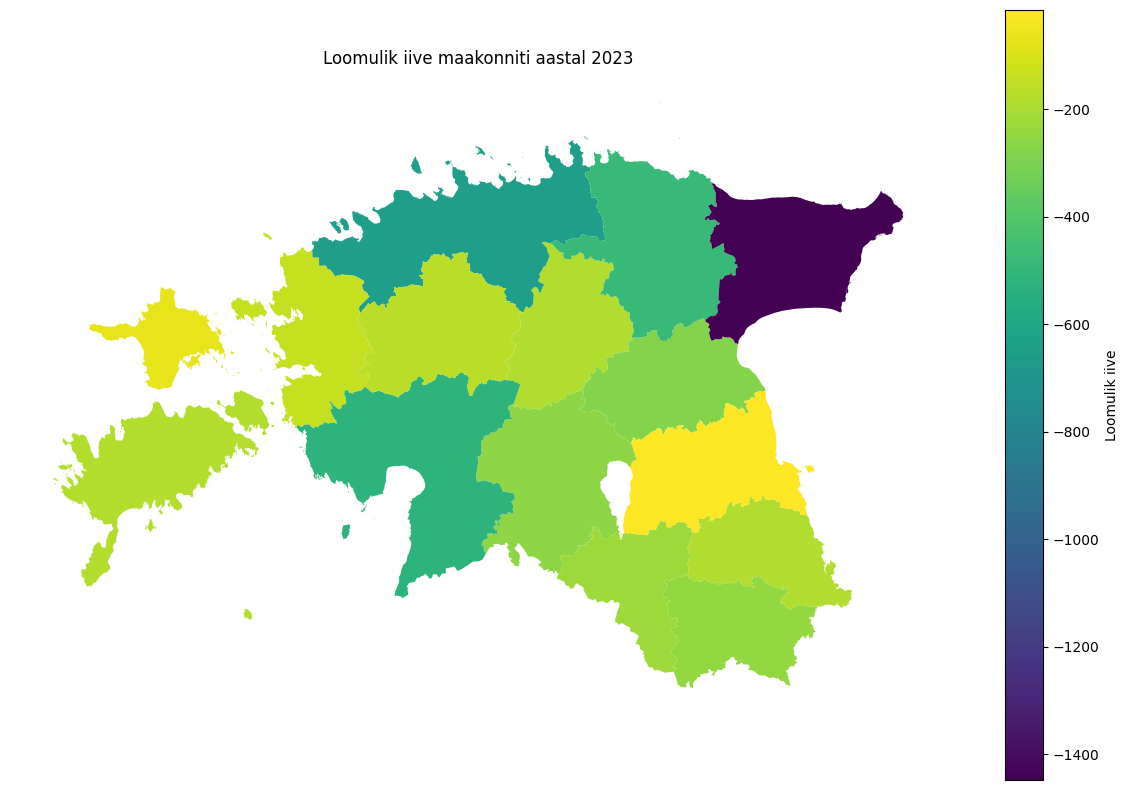

In [16]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Replace 'value_column' with the column name you want to visualize
aasta_2023.plot(column='Loomulik iive', 
                 ax=ax,
                 legend=True,
                 cmap='viridis',  # Choose a colormap
                 legend_kwds={'label': "Loomulik iive"})

plt.title('Loomulik iive maakonniti aastal 2023')
plt.axis('off')  # Hide axis
plt.tight_layout()
plt.show()


Järgmises lahtris kogu eelnev kood on pandud kokku, selleks et seda oleks mugavam nüüd juurutada: 

In [17]:
import requests
import pandas as pd
from io import StringIO
import json
import geopandas as gpd
import matplotlib.pyplot as plt

STATISTIKAAMETI_API_URL = "https://andmed.stat.ee/api/v1/et/stat/RV032"

JSON_PAYLOAD_STR =""" {
  "query": [
    {
      "code": "Aasta",
      "selection": {
        "filter": "item",
        "values": [
          "2014",
          "2015",
          "2016",
          "2017",
          "2018",
          "2019",
          "2020",
          "2021",
          "2022",
          "2023"
        ]
      }
    },
    {
      "code": "Maakond",
      "selection": {
        "filter": "item",
        "values": [
          "39",
          "44",
          "49",
          "51",
          "57",
          "59",
          "65",
          "67",
          "70",
          "74",
          "78",
          "82",
          "84",
          "86",
          "37"
        ]
      }
    },
    {
      "code": "Sugu",
      "selection": {
        "filter": "item",
        "values": [
          "2",
          "3"
        ]
      }
    }
  ],
  "response": {
    "format": "csv"
  }
}
"""
geojson = "maakonnad.geojson"
    

def import_data():
    headers = {
        'Content-Type': 'application/json'  # or application/x-www-form-urlencoded if needed
    }
    
    parsed_payload = json.loads(JSON_PAYLOAD_STR)
    
    
    response = requests.post(STATISTIKAAMETI_API_URL, json=parsed_payload, headers=headers)
    
    if response.status_code == 200:
        print("Request successful.")       
        text = response.content.decode('utf-8-sig')
        df = pd.read_csv(StringIO(text))

    else:
        print(f"Failed with status code: {response.status_code}")
        print(response.text)
    return df

def import_geojson():
    gdf = gpd.read_file(geojson)
    return gdf

def get_data_for_year(df, year):
    year_data = df[df.Aasta==year]
    return year_data

def plot(df):
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Replace 'value_column' with the column name you want to visualize
    df.plot(column='Loomulik iive', 
                     ax=ax,
                     legend=True,
                     cmap='viridis',  # Choose a colormap
                     legend_kwds={'label': "Loomulik iive"})
    
    plt.title('Loomulik iive maakonniti aastal 2023')
    plt.axis('off')  # Hide axis
    plt.tight_layout()
    plt.show()

Request successful.


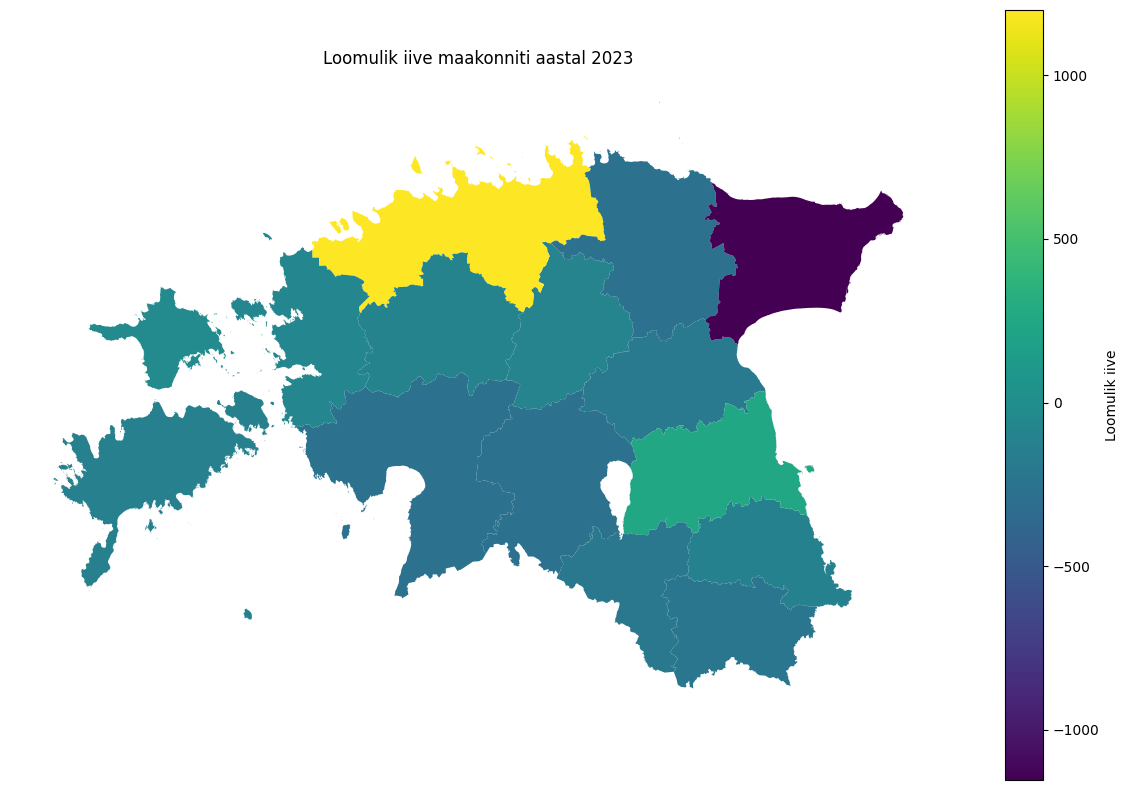

In [18]:
df = import_data()
merged_data = gdf.merge(df, left_on='MNIMI', right_on='Maakond') 
merged_data["Loomulik iive"] = merged_data["Mehed Loomulik iive"] + merged_data["Naised Loomulik iive"]
plot(get_data_for_year(merged_data, 2017))

# Iseseisva ülesanne algus

**Streamlit teenus**

Streamlit on Pythoni avatud lähtekoodiga raamistik, mis on loodud spetsiaalselt andmeteadlastele ja inseneridele, et kergelt ja kiirelt (ja tasuta) luua veebirakendusi andmeanalüüsiks ja visualiseerimiseks. See võimaldab muuta Pythoni skriptid interaktiivseteks veebirakendusteks ilma, et oleks vaja põhjalikke teadmisi veebirakenduste arendamisest.

See annab võimalust: 

- Visualiseerida andmeid ja analüüsi tulemusi
- Luua interaktiivne töölauad (dashboard)
- Luua liides masinõppemudelite kasutamiseks
- Testida ja esitleda ideid


Streamlit on eriti kasulik olukorras, kus andmeteadlane või arendaja soovib kiiresti luua interaktiivse veebirakenduse ilma, et peaks õppima keerukamaid veebiraamistikke nagu Flask, Django

**Kasutades eelnevalt kirjutatud koodi, looge Streamlit töölaud, kus saab valida aastat ja töölauas uueneb pilt.** 

Siin on näide sarnasest rakendusest: 
https://census-explorer.streamlit.app/
Klõpsake github ikoonil selleks et näha rakenduse lähtekoodi.


Selleks et juurutada oma rakendust Streamlit'is, pange eelnevalt ette valmistatud kood githubi faili `app.py`, lisage Streamlit'i jaoks vajalikku nuppu selleks et valida aasta (`st.sidebar.selectbox`) ja teisi vajalikke funktsioone. Järgige järgmist õppetust ja/või sarnase rakenduse näidist: 

https://docs.streamlit.io/get-started/tutorials/create-an-app

Võite ka kasutada mõne ChatBoti abi selleks et luua oma rakendus. 

**Ülesanne vastus: pange oma töölaua link SIIA**